# Finetuned Model Evaluation — Recommendation Metrics

Compares four fine-tuned models against each other using the `recommend.py`
recommendation pipeline from the LLM-Playlist-Recommender repo.

**Models evaluated:**
| Model | Cluster source | Loss |
|---|---|---|
| FKM Fuzzy | Fuzzy K-Means (all playlists) | Soft cross-entropy |
| FKM Pruned | Fuzzy K-Means (LSH-pruned) | Hard cross-entropy |
| HDBSCAN | HDBSCAN (all non-noise) | Hard cross-entropy |
| HDBSCAN Pruned | HDBSCAN (LSH-pruned) | Hard cross-entropy |

**Metrics:** HIT@N, Precision@N, Recall@N, MRR@N, R-Precision, NDCG

**Pipeline per model:**
1. Load fine-tuned `AutoModelForSequenceClassification` (via `playlists_embeddings_final.py`)
2. Pre-compute + cache playlist embeddings for all playlists in `playlists.csv`
3. For each test playlist title → find top-50 similar playlists (vectorised cosine sim)
4. Aggregate top-K tracks via `recommend.get_top_songs_with_artists()`
5. Compare against the playlist's own ground-truth tracks → compute metrics


### Step 1: Setup (drive mounting, paths)


In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Project paths (match finetuning notebooks)
DRIVE_BASE   = "/content/drive/MyDrive/S2026/Spotify Playlist Data/Processed Data/calced_embeddings"
PROJECT_BASE = "/content/drive/MyDrive/S2026/CS 274/Playlist-Recommender"

# CSV data folder (Spotify MPD: items.csv, tracks.csv, playlists.csv)
CSV_FOLDER   = "/content/drive/MyDrive/S2026/Spotify Playlist Data/Processed Data/csvs"
ITEMS_CSV    = os.path.join(CSV_FOLDER, "items.csv")
TRACKS_CSV   = os.path.join(CSV_FOLDER, "tracks.csv")
PLAYLISTS_CSV = os.path.join(CSV_FOLDER, "playlists.csv")

# Finetuned model directories
MODELS = {
    "FKM Fuzzy"     : f"{PROJECT_BASE}/fuzzy_finetuned_model",
    "FKM Pruned"    : f"{PROJECT_BASE}/fuzzy_finetuned_model_pruned_minilm",
    "HDBSCAN"       : f"{PROJECT_BASE}/hdbscan_finetuned_model",
    "HDBSCAN Pruned": f"{PROJECT_BASE}/hdbscan_finetuned_model_pruned",
}

# Cached playlist-embedding pkl paths (one per model)
EMBEDDINGS_CACHE_DIR = f"{PROJECT_BASE}/metrics_embeddings"
os.makedirs(EMBEDDINGS_CACHE_DIR, exist_ok=True)

EMBEDDINGS_FILES = {
    name: os.path.join(EMBEDDINGS_CACHE_DIR, f"{name.lower().replace(' ', '_')}_embeddings.pkl")
    for name in MODELS
}

# Evaluation config
TOP_K = 10      # songs returned per query
TOP_PLAYLISTS = 50   # candidate playlists to aggregate tracks from

print("Paths configured.")
for name, path in MODELS.items():
    print(f"  {name}: {path}")


Mounted at /content/drive
Paths configured.
  FKM Fuzzy: /content/drive/MyDrive/S2026/CS 274/Playlist-Recommender/fuzzy_finetuned_model
  FKM Pruned: /content/drive/MyDrive/S2026/CS 274/Playlist-Recommender/fuzzy_finetuned_model_pruned_minilm
  HDBSCAN: /content/drive/MyDrive/S2026/CS 274/Playlist-Recommender/hdbscan_finetuned_model
  HDBSCAN Pruned: /content/drive/MyDrive/S2026/CS 274/Playlist-Recommender/hdbscan_finetuned_model_pruned


### Step 2: Clone repos and install dependencies


In [2]:
import os

RECSYS_REPO_DIR = "/content/RecsysUpgrade"
LLM_REPO_DIR    = "/content/RecsysUpgrade" # LLM code is now within RecsysUpgrade

if not os.path.exists(RECSYS_REPO_DIR):
    !git clone https://github.com/siddmohanty111/RecsysUpgrade.git {RECSYS_REPO_DIR}
else:
    !git -C {RECSYS_REPO_DIR} pull

print("Repos ready.")

Cloning into '/content/RecsysUpgrade'...
remote: Enumerating objects: 219, done.
remote: Counting objects: 100% (219/219), done.
remote: Compressing objects: 100% (178/178), done.
remote: Total 219 (delta 98), reused 142 (delta 38), pack-reused 0 (from 0)
Receiving objects: 100% (219/219), 4.66 MiB | 34.82 MiB/s, done.
Resolving deltas: 100% (98/98), done.
Repos ready.


In [3]:
!pip install -q -r {RECSYS_REPO_DIR}/requirements.txt
!pip install -q scikit-learn tqdm pandas matplotlib
print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.0/833.0 kB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
Dependencies installed.


### Step 3: Imports


In [5]:
import sys
import importlib.util
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity

# ── Load playlists_embeddings_final (correct model loader for our models) ──
_emb_spec = importlib.util.spec_from_file_location(
    "playlists_embeddings_final",
    os.path.join(RECSYS_REPO_DIR, "src", "LLM-Playlist-Recommender", "embeddings", "playlists_embeddings_final.py")
)
playlists_emb_mod = importlib.util.module_from_spec(_emb_spec)
sys.modules["playlists_embeddings_final"] = playlists_emb_mod
_emb_spec.loader.exec_module(playlists_emb_mod);

# ── Load recommend (utility functions: track loading, top-songs, metrics) ──
sys.path.insert(0, os.path.join(RECSYS_REPO_DIR, "src", "LLM-Playlist-Recommender", "similarity"))
import recommend as recommend_mod

print("Modules loaded.")
print(f"  playlists_embeddings_final: {playlists_emb_mod.__file__}")
print(f"  recommend: {recommend_mod.__file__}")

Modules loaded.
  playlists_embeddings_final: /content/RecsysUpgrade/src/LLM-Playlist-Recommender/embeddings/playlists_embeddings_final.py
  recommend: /content/RecsysUpgrade/src/LLM-Playlist-Recommender/similarity/recommend.py


### Step 4: Load shared resources


In [ ]:
# Load playlist track data once — shared across all model evaluations.
# recommend.load_playlist_tracks_with_artists returns:
#   {pid_str: [{"track_name": ..., "artist_name": ...}, ...]}
print("Loading playlist tracks …")
playlist_tracks = recommend_mod.load_playlist_tracks_with_artists(ITEMS_CSV, TRACKS_CSV)
print(f"  Loaded tracks for {len(playlist_tracks):,} playlists.")


Loading playlist tracks …


Loading track metadata: 2262292track [00:12, 188446.67track/s]
Loading playlist tracks: 66346428playlist [02:47, 396468.15playlist/s]


  Loaded tracks for 1,000,000 playlists.


In [ ]:
# 22-playlist evaluation set (from testset_test_model_args.py in LLM-Playlist-Recommender)
# Each entry: (cluster_id_unused, pid_str, title)
TEST_SET = [
    (None, "673925",  "K-pop"),
    (None, "677580",  "workout music"),
    (None, "321143",  "Dance"),
    (None, "923247",  "Rock"),
    (None, "301195",  "Summer"),
    (None, "490485",  "Hawaii"),
    (None, "575612",  "Classic Country"),
    (None, "269088",  "older songs"),
    (None, "606436",  "2016"),
    (None, "701866",  "Dance"),
    (None, "608829",  "FINESSE"),
    (None, "273344",  "Oldies"),
    (None, "501054",  "Rock"),
    (None, "750528",  "sports"),
    (None, "684261",  "Christian"),
    (None, "44648",   "gaming"),
    (None, "837665",  "classics"),
    (None, "786219",  "Party"),
    (None, "47214",   "workout"),
    (None, "889395",  "work"),
    (None, "497427",  "Love songs"),
    (None, "677006",  "Summer"),
]

# Remove test playlists for which we have no ground-truth tracks
valid_test_set = [(cid, pid, title) for cid, pid, title in TEST_SET if pid in playlist_tracks]
print(f"Test set: {len(valid_test_set)}/{len(TEST_SET)} playlists have ground-truth tracks.")


Test set: 22/22 playlists have ground-truth tracks.


### Step 5: Embedding helpers

`playlists_embeddings_final.load_fine_tuned_model` uses
`AutoModelForSequenceClassification` with `output_hidden_states=True` and
pulls the last hidden state — required for our saved models.  
`recommend.load_fine_tuned_model` uses `AutoModel` and would silently
return zero/wrong embeddings, so we never call it.


In [ ]:
def load_or_compute_embeddings(model_name, model_dir, embeddings_pkl, playlists_csv):
    """
    Load cached playlist embeddings if available; otherwise compute and save them.
    Uses playlists_embeddings_final.load_fine_tuned_model (AutoModelForSequenceClassification
    with output_hidden_states=True) — NOT recommend.load_fine_tuned_model (AutoModel).

    Returns: (tokenizer, model, device, playlist_embeddings dict)
    """
    tokenizer, model, device = playlists_emb_mod.load_fine_tuned_model(model_dir)

    if os.path.exists(embeddings_pkl):
        print(f"[{model_name}] Loading cached embeddings from {embeddings_pkl} …")
        with open(embeddings_pkl, "rb") as f:
            playlist_embeddings = pickle.load(f)
        print(f"[{model_name}] Loaded {len(playlist_embeddings):,} playlist embeddings.")
    else:
        print(f"[{model_name}] Computing playlist embeddings (this may take a while) …")
        playlists_emb_mod.compute_and_save_playlist_embeddings(
            playlists_csv, embeddings_pkl, tokenizer, model, device
        )
        with open(embeddings_pkl, "rb") as f:
            playlist_embeddings = pickle.load(f)
        print(f"[{model_name}] Computed and saved {len(playlist_embeddings):,} playlist embeddings.")

    return tokenizer, model, device, playlist_embeddings


def find_similar_playlists_finetuned(query_title, playlist_embeddings, tokenizer, model, device, top_k=50):
    """
    Vectorised cosine-similarity search over all pre-computed playlist embeddings.
    Uses playlists_embeddings_final.get_embedding to embed the query title.
    Returns: [(pid_str, similarity_score), ...] sorted descending, length top_k.
    """
    query_vec = playlists_emb_mod.get_embedding(query_title, tokenizer, model, device)
    query_vec = np.array(query_vec).reshape(1, -1)

    pids = list(playlist_embeddings.keys())
    matrix = np.array([playlist_embeddings[pid]["embedding"] for pid in pids])

    sims = cosine_similarity(query_vec, matrix)[0]
    top_indices = np.argsort(sims)[::-1][:top_k]
    return [(pids[i], float(sims[i])) for i in top_indices]

print("Helper functions defined.")


Helper functions defined.


### Step 6: Evaluate each model


In [ ]:
def evaluate_model(model_name, model_dir, embeddings_pkl, test_set, playlist_tracks,
                   playlists_csv, top_k=10, top_playlists=50):
    """
    Full evaluation pipeline for a single fine-tuned model.

    For each test playlist:
      1. Find top_playlists most similar playlists by embedding cosine similarity
      2. Aggregate top_k tracks from those playlists (recommend.get_top_songs_with_artists)
      3. Compare against ground-truth tracks of the test playlist
      4. Compute metrics via recommend.compute_metrics

    Returns: dict of mean metrics over the test set.
    """
    tokenizer, model, device, playlist_embeddings = load_or_compute_embeddings(
        model_name, model_dir, embeddings_pkl, playlists_csv
    )

    all_metrics = []
    skipped = 0

    for _, test_pid, playlist_title in tqdm(test_set, desc=f"Evaluating [{model_name}]", unit="playlist"):
        # Ground truth: list of (track_name, artist_name) tuples for this playlist
        raw_tracks = playlist_tracks.get(str(test_pid), [])
        if not raw_tracks:
            skipped += 1
            continue
        relevant_songs = [(d["track_name"], d["artist_name"]) for d in raw_tracks]

        # Find similar playlists (exclude the test playlist itself)
        similar_playlists = find_similar_playlists_finetuned(
            playlist_title, playlist_embeddings, tokenizer, model, device, top_k=top_playlists + 1
        )
        similar_playlists = [(pid, score) for pid, score in similar_playlists if pid != str(test_pid)]
        similar_playlists = similar_playlists[:top_playlists]

        # Aggregate top tracks across similar playlists
        # recommend.get_top_songs_with_artists returns [((track_name, artist_name), count), ...]
        top_songs = recommend_mod.get_top_songs_with_artists(similar_playlists, playlist_tracks, top_k=top_k)
        recommended_songs = [song for song, _count in top_songs]  # list of (track_name, artist_name)

        # Compute metrics
        metrics = recommend_mod.compute_metrics(recommended_songs, relevant_songs, top_n=top_k)
        all_metrics.append(metrics)

    if not all_metrics:
        print(f"[{model_name}] WARNING: No valid test playlists — all {skipped} were skipped.")
        return {}

    mean_metrics = {k: float(np.mean([m[k] for m in all_metrics])) for k in all_metrics[0]}
    print(f"[{model_name}] Done. Evaluated {len(all_metrics)} playlists, skipped {skipped}.")
    return mean_metrics

print("evaluate_model() defined.")


evaluate_model() defined.


In [ ]:
all_results = {}

for model_name, model_dir in MODELS.items():
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"  Dir: {model_dir}")
    print(f"{'='*60}")

    mean_metrics = evaluate_model(
        model_name        = model_name,
        model_dir         = model_dir,
        embeddings_pkl    = EMBEDDINGS_FILES[model_name],
        test_set          = valid_test_set,
        playlist_tracks   = playlist_tracks,
        playlists_csv     = PLAYLISTS_CSV,
        top_k             = TOP_K,
        top_playlists     = TOP_PLAYLISTS,
    )
    all_results[model_name] = mean_metrics

print("\nAll models evaluated.")



Model: FKM Fuzzy
  Dir: /content/drive/MyDrive/S2026/CS 274/Playlist-Recommender/fuzzy_finetuned_model


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

[FKM Fuzzy] Computing playlist embeddings (this may take a while) …


Computing embeddings: 100%|██████████| 1000000/1000000 [1:23:39<00:00, 199.23playlist/s]


Playlist embeddings saved successfully to /content/drive/MyDrive/S2026/CS 274/Playlist-Recommender/metrics_embeddings/fkm_fuzzy_embeddings.pkl.
[FKM Fuzzy] Computed and saved 1,000,000 playlist embeddings.


...

[HDBSCAN Pruned] Computing playlist embeddings (this may take a while) …


Computing embeddings: 100%|██████████| 1000000/1000000 [1:22:40<00:00, 201.58playlist/s]


Playlist embeddings saved successfully to /content/drive/MyDrive/S2026/CS 274/Playlist-Recommender/metrics_embeddings/hdbscan_pruned_embeddings.pkl.
[HDBSCAN Pruned] Computed and saved 1,000,000 playlist embeddings.


Evaluating [HDBSCAN Pruned]: 100%|██████████| 22/22 [00:48<00:00,  2.21s/playlist]


[HDBSCAN Pruned] Done. Evaluated 22 playlists, skipped 0.

All models evaluated.


### Step 7: Results comparison


In [ ]:
# Summary table
results_df = pd.DataFrame(all_results).T
results_df.index.name = "Model"
results_df = results_df[["HIT@N", "Precision@N", "Recall@N", "MRR@N", "R-Precision", "NDCG"]]

pd.set_option("display.float_format", "{:.4f}".format)
display(results_df)


,HIT@N,Precision@N,Recall@N,MRR@N,R-Precision,NDCG
Model,,,,,,
FKM Fuzzy,0.2182,0.2182,0.0392,0.4860,0.0526,0.4966
FKM Pruned,0.2091,0.2091,0.0386,0.3641,0.0515,0.4437
HDBSCAN,0.2227,0.2227,0.0432,0.3924,0.0576,0.4206
HDBSCAN Pruned,0.1818,0.1818,0.0339,0.3455,0.0465,0.4383


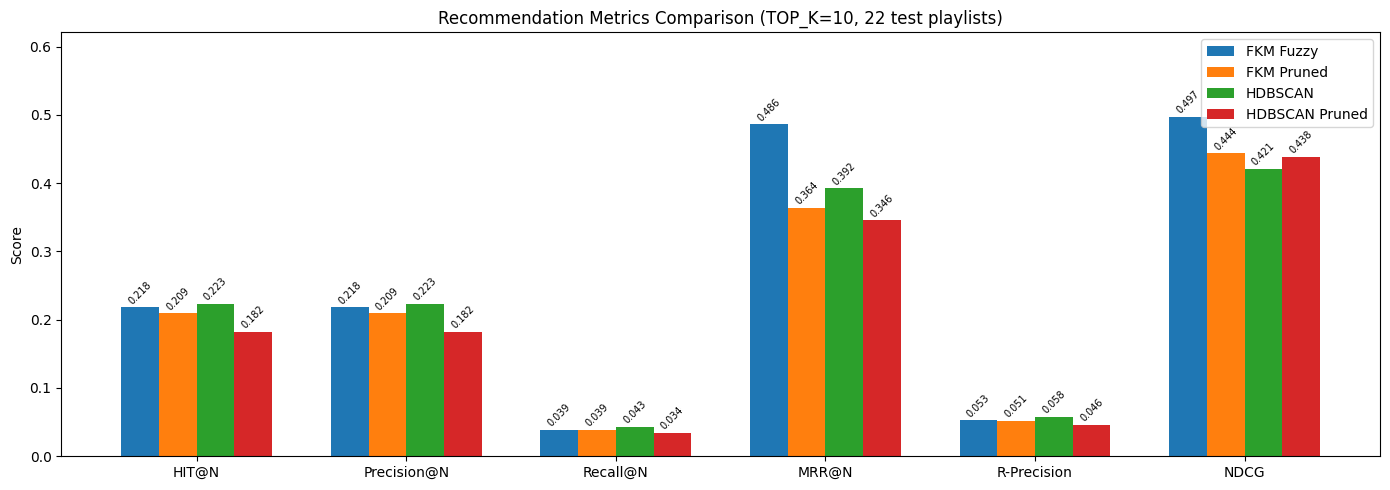

Plot saved to metrics_comparison.png


In [ ]:
# Bar chart — all metrics by model
metrics_to_plot = ["HIT@N", "Precision@N", "Recall@N", "MRR@N", "R-Precision", "NDCG"]
n_metrics = len(metrics_to_plot)
model_names = list(results_df.index)
n_models = len(model_names)
bar_width = 0.18
x = np.arange(n_metrics)

fig, ax = plt.subplots(figsize=(14, 5))
for i, name in enumerate(model_names):
    offsets = x + (i - n_models / 2 + 0.5) * bar_width
    values = [results_df.loc[name, m] for m in metrics_to_plot]
    bars = ax.bar(offsets, values, bar_width, label=name)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=7, rotation=45
        )

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Score")
ax.set_title(f"Recommendation Metrics Comparison (TOP_K={TOP_K}, {len(valid_test_set)} test playlists)")
ax.legend(loc="upper right")
ax.set_ylim(0, max(results_df.values.max() * 1.25, 0.1))
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_BASE, "metrics_comparison.png"), dpi=150)
plt.show()
print("Plot saved to metrics_comparison.png")


In [ ]:
# Best model per metric
print("Best model per metric:")
for metric in metrics_to_plot:
    best = results_df[metric].idxmax()
    print(f"  {metric:15s}: {best}  ({results_df.loc[best, metric]:.4f})")

# Save results to CSV
out_csv = os.path.join(PROJECT_BASE, "metrics_comparison.csv")
results_df.to_csv(out_csv)
print(f"\nResults saved to {out_csv}")


Best model per metric:
  HIT@N          : HDBSCAN  (0.2227)
  Precision@N    : HDBSCAN  (0.2227)
  Recall@N       : HDBSCAN  (0.0432)
  MRR@N          : FKM Fuzzy  (0.4860)
  R-Precision    : HDBSCAN  (0.0576)
  NDCG           : FKM Fuzzy  (0.4966)

Results saved to /content/drive/MyDrive/S2026/CS 274/Playlist-Recommender/metrics_comparison.csv
